# Prepare the enviroment

In [1]:
LOCAL = True

In [2]:
import os
import json
import trimesh
import datetime

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path

from bunny.utils import load_mesh, pointcloud_to_mesh, visualize_transition, visualize_transition_3d, interpolate_pointclouds
from bunny.model import VectorFieldNet, load_model
from evaluate import evaluate_all

In [3]:
def get_timestamp() -> str:
    ct = datetime.datetime.now()

    return ct.strftime("%Y-%m-%d_%H-%M-%S")

In [4]:
if LOCAL:
    PROJ_ROOT = Path(os.getcwd()).parents[0]

    MODELS_DIR = PROJ_ROOT / "modele"
    BUNNY_OBJECT_PATH = MODELS_DIR / "bunny.obj"
    TEAPOT_OBJECT_PATH = MODELS_DIR / "teapot.obj"

    BUNNY_PIPELINE_DIR = PROJ_ROOT / "bunny"

    RUNS_DIR = BUNNY_PIPELINE_DIR / "checkpoints"
    CURRENT_RUN_DIR = RUNS_DIR / get_timestamp()
    CURRENT_RUN_DIR.mkdir(parents=True, exist_ok=True)
else:
    raise NotImplementedError("Not implemented yet.")

print(f"Project root: {PROJ_ROOT} (exists: {PROJ_ROOT.exists()}) \n")
print(f"Models dir: {MODELS_DIR} (exists: {MODELS_DIR.exists()}) \n")
print(f"Bunny object: {BUNNY_OBJECT_PATH} (exists: {BUNNY_OBJECT_PATH.exists()}) \n")
print(f"Teapot object: {TEAPOT_OBJECT_PATH} (exists: {TEAPOT_OBJECT_PATH.exists()}) \n")
print(f"Runs dir: {RUNS_DIR} (exists: {RUNS_DIR.exists()}) \n")
print(f"Current run dir: {CURRENT_RUN_DIR} (exists: {CURRENT_RUN_DIR.exists()}) \n")

Project root: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project4-3d-transformation (exists: True) 

Models dir: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project4-3d-transformation/modele (exists: True) 

Bunny object: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project4-3d-transformation/modele/bunny.obj (exists: True) 

Teapot object: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project4-3d-transformation/modele/teapot.obj (exists: True) 

Runs dir: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project4-3d-transformation/bunny/checkpoints (exists: True) 

Current run dir: /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project4-3d-transformation/bunny/checkpoints/2026-05-11_16-38-35 (exists: True) 



In [5]:
N_POINTS = 2048
BATCH_SIZE = 4
EPOCHS = 200
LR = 1e-3
FLOW_STEPS = 10

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE} \n")

Using device: cuda 



# Load the data

## Load the target object (teapot)

In [7]:
def load_object(path: Path, n_points: int) -> np.ndarray:
    mesh = trimesh.load(path, force="mesh")
    points, _ = trimesh.sample.sample_surface(mesh, n_points)

    return points.astype(np.float32)

In [8]:
target_raw = load_object(TEAPOT_OBJECT_PATH, N_POINTS)
print(f"Loaded target object teapot with shape: {target_raw.shape}")

Loaded target object teapot with shape: (2048, 3)


In [9]:
def normalize_points(points: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    centroid = points.mean(axis=0)
    points = points - centroid
    scale = np.linalg.norm(points, axis=1).max()
    points = points / (scale + 1e-8)

    return points, centroid, scale

In [10]:
target_norm, _, _ = normalize_points(target_raw)
print(f"Normalized target object teapot with shape: {target_norm.shape}")

Normalized target object teapot with shape: (2048, 3)


In [11]:
target_t = torch.tensor(target_norm, device=DEVICE)
print(f"Teapot tensor shape: {target_t.shape} and dtype: {target_t.dtype}")

Teapot tensor shape: torch.Size([2048, 3]) and dtype: torch.float32


## Load the source object (bunny)

In [12]:
def random_rotation_matrix() -> np.ndarray:
    q, _ = np.linalg.qr(np.random.randn(3, 3))

    if np.linalg.det(q) < 0:
        q[:, 0] *= -1

    return q.astype(np.float32)

In [13]:
def augment_points(points: np.ndarray, rotate: bool = True, scale_range: tuple = (0.8, 1.2)) -> np.ndarray:
    if rotate:
        R = random_rotation_matrix()
        points = points @ R.T

    s = np.random.uniform(*scale_range)
    points = points * s

    return points

In [14]:
class MeshDataset(torch.utils.data.Dataset):
    def __init__(
            self,
            mesh_path: str,
            n_points: int = 2048,
            augment: bool = True,
            scale_range: tuple = (0.8, 1.2),
            dataset_size: int = 1000
    ):
        self.mesh = trimesh.load(mesh_path, force="mesh")
        self.n_points = n_points
        self.augment = augment
        self.scale_range = scale_range
        self.dataset_size = dataset_size

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        pts, _ = trimesh.sample.sample_surface(self.mesh, self.n_points)
        pts = pts.astype(np.float32)
        pts, _, _ = normalize_points(pts)

        if self.augment:
            pts = augment_points(pts, rotate=True, scale_range=self.scale_range)

        return torch.tensor(pts)

In [15]:
dataset = MeshDataset(BUNNY_OBJECT_PATH, n_points=N_POINTS, augment=True, dataset_size=BATCH_SIZE * EPOCHS)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Created dataset with virtual size: {len(dataset)} and dataloader with batch size: {BATCH_SIZE}")

Created dataset with virtual size: 800 and dataloader with batch size: 4


# Model

In [16]:
model = VectorFieldNet().to(DEVICE)
print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters.")

Model initialized with 363011 parameters.


# Training

In [17]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

checkpoint_path = CURRENT_RUN_DIR / "bunny_to_teapot.pt"

In [18]:
def integrate_flow(model: nn.Module, points: torch.Tensor, steps: int = 10) -> tuple[torch.Tensor, list[torch.Tensor]]:
    trajectory = [points.clone()]
    dt = 1.0 / steps
    x = points

    for _ in range(steps):
        v = model(x)
        x = x + v * dt

        trajectory.append(x.clone())

    return x, trajectory

In [19]:
def chamfer_distance(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    if p.dim() == 2:
        p = p.unsqueeze(0)
        q = q.unsqueeze(0)

    diff = p.unsqueeze(2) - q.unsqueeze(1)
    dist2 = (diff ** 2).sum(-1)

    d_p = dist2.min(dim=2).values.mean()
    d_q = dist2.min(dim=1).values.mean()

    return (d_p + d_q) * 0.5

In [20]:
losses = []
print(f"Training BUNNY → TEAPOT for {EPOCHS} epochs …")

device_t = torch.device(DEVICE)
step = 0

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0

    for batch in loader:
        if step >= EPOCHS:
            break

        model.train()
        optimizer.zero_grad()

        src = batch.to(device_t)
        tgt = target_t.unsqueeze(0).expand(src.size(0), -1, -1)

        B, N, _ = src.shape
        src_flat = src.reshape(B * N, 3)
        pred_flat, _ = integrate_flow(model, src_flat, steps=FLOW_STEPS)
        pred = pred_flat.reshape(B, N, 3)

        loss = chamfer_distance(pred, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        step += 1

    losses.append(epoch_loss)

    print(f"  Epoch {epoch:4d}/{EPOCHS}  Loss={epoch_loss:.6f}")

torch.save(model.state_dict(), checkpoint_path)
print(f"Saved model → {checkpoint_path}")

Training BUNNY → TEAPOT for 200 epochs …
  Epoch    1/200  Loss=0.357305
  Epoch    2/200  Loss=0.000000
  Epoch    3/200  Loss=0.000000
  Epoch    4/200  Loss=0.000000
  Epoch    5/200  Loss=0.000000
  Epoch    6/200  Loss=0.000000
  Epoch    7/200  Loss=0.000000
  Epoch    8/200  Loss=0.000000
  Epoch    9/200  Loss=0.000000
  Epoch   10/200  Loss=0.000000
  Epoch   11/200  Loss=0.000000
  Epoch   12/200  Loss=0.000000
  Epoch   13/200  Loss=0.000000
  Epoch   14/200  Loss=0.000000
  Epoch   15/200  Loss=0.000000
  Epoch   16/200  Loss=0.000000
  Epoch   17/200  Loss=0.000000
  Epoch   18/200  Loss=0.000000
  Epoch   19/200  Loss=0.000000
  Epoch   20/200  Loss=0.000000
  Epoch   21/200  Loss=0.000000
  Epoch   22/200  Loss=0.000000
  Epoch   23/200  Loss=0.000000
  Epoch   24/200  Loss=0.000000
  Epoch   25/200  Loss=0.000000
  Epoch   26/200  Loss=0.000000
  Epoch   27/200  Loss=0.000000
  Epoch   28/200  Loss=0.000000
  Epoch   29/200  Loss=0.000000
  Epoch   30/200  Loss=0.000000

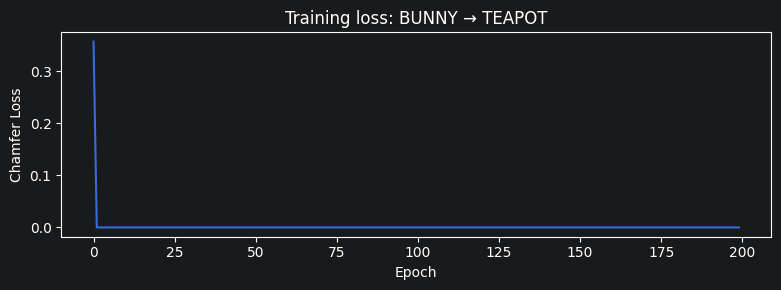

In [21]:
plt.figure(figsize=(8, 3))
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Chamfer Loss")
plt.title(f"Training loss: BUNNY → TEAPOT")

plt.tight_layout()
plt.savefig(CURRENT_RUN_DIR / "loss.png", dpi=120)
plt.show()
plt.close()

# Evaluation

In [22]:
model = load_model(checkpoint_path, device=DEVICE)

In [23]:
def normalize_pointcloud(points: np.ndarray) -> np.ndarray:
    points = points - points.mean(axis=0)
    scale = np.linalg.norm(points, axis=1).max()

    return points / scale

In [24]:
def transform_mesh(obj_path: Path, model, device, n_points: int) -> np.ndarray:
    pts = normalize_pointcloud(load_object(obj_path, n_points))
    tensor = torch.from_numpy(pts).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(tensor).squeeze(0).cpu().numpy()

    return pred

In [25]:
model.eval()

teapot_mesh = load_mesh(TEAPOT_OBJECT_PATH)

pred_points = transform_mesh(BUNNY_OBJECT_PATH, model, DEVICE, N_POINTS)
pred_mesh = pointcloud_to_mesh(pred_points)

metrics = evaluate_all(pred_mesh, teapot_mesh, n_points=N_POINTS, resolution=64)
json.dump(metrics, open(CURRENT_RUN_DIR / "metrics.json", "w"), indent=4)

In [26]:
print("=== Bunny flow — metrics ===")
print(f"  IoU     : {metrics['iou']:.4f}")
print(f"  Dice    : {metrics['dice']:.4f}")
print(f"  Chamfer : {metrics['chamfer']:.6f}")

=== Bunny flow — metrics ===
  IoU     : 0.2779
  Dice    : 0.4349
  Chamfer : 3.345814


# Visualisation

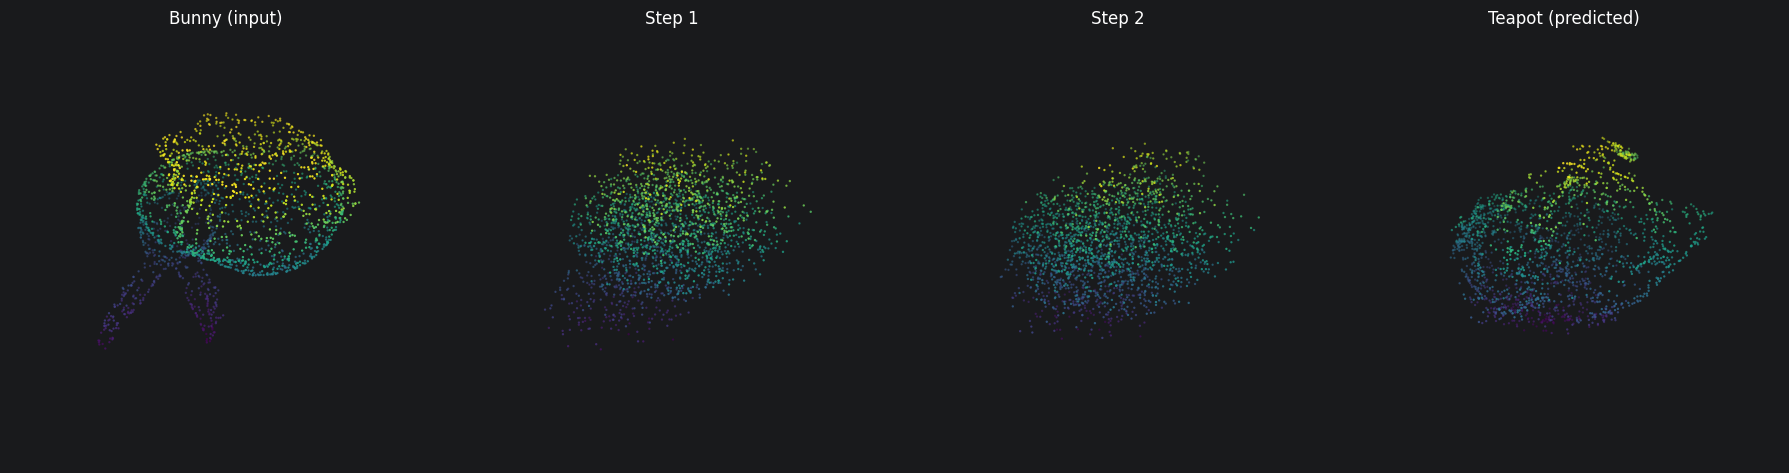

In [27]:
model.eval()

src_pts = normalize_pointcloud(load_object(BUNNY_OBJECT_PATH, N_POINTS))
pred_pts = transform_mesh(BUNNY_OBJECT_PATH, model, DEVICE, N_POINTS)

steps = interpolate_pointclouds(src_pts, pred_pts, steps=4)

visualize_transition(
    steps,
    titles=["Bunny (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)

In [29]:
visualize_transition_3d(
    steps,
    titles=["Bunny (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)